# Data Validation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all the CSVs into DataFrames
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
product_category_name_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

## 1. `orders` table

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
# Check uniqueness of keys
print("order_id uniqueness:", orders["order_id"].is_unique)

order_id uniqueness: True


In [4]:
ts_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]

orders[ts_cols] = orders[ts_cols].apply(pd.to_datetime, errors="coerce")

print("Data types after conversion:")
print(orders.dtypes)

Data types after conversion:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object


In [5]:
# --------------------------
# Business Checks 
# --------------------------
# Rule 1: Miniumum number of timestamps based on order_status
status_rules = {
    "created": ["order_purchase_timestamp"],
    "approved": ["order_purchase_timestamp", "order_approved_at"],
    "invoiced": ["order_purchase_timestamp", "order_approved_at"],
    "processing": ["order_purchase_timestamp", "order_approved_at"],
    "shipped": ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date"],
    "delivered": ["order_purchase_timestamp", "order_approved_at", "order_delivered_customer_date"],
}

def missing_required_ts(row):
    required = status_rules.get(row["order_status"], [])
    return any(pd.isna(row[col]) for col in required)

orders["missing_required_timestamps"] = orders.apply(missing_required_ts, axis=1)

num_missing_required_timestamps = orders["missing_required_timestamps"].sum()
print(f"Number of orders missing required timestamps based on status: {num_missing_required_timestamps}")

Number of orders missing required timestamps based on status: 22


In [6]:
# Rule 2: Status aware timestamp ordering
def status_aware_ordering(row):
    if row["order_status"] in ["created"]:
        return True
    if row["order_status"] in ["approved", "invoiced", "processing"]:
        return row["order_purchase_timestamp"] <= row["order_approved_at"]
    if row["order_status"] == "shipped":
        return (
            row["order_purchase_timestamp"] <= row["order_approved_at"] <=
            row["order_delivered_carrier_date"]
        )
    if row["order_status"] == "delivered":
        return (
            row["order_purchase_timestamp"] <= row["order_approved_at"] <=
            row["order_delivered_carrier_date"] <=
            row["order_delivered_customer_date"]
        )
    return True

orders["status_aware_ordering"] = orders.apply(status_aware_ordering, axis=1)

num_invalid_orderings = (~orders["status_aware_ordering"]).sum()
print(f"Number of orders with invalid timestamp orderings based on status: {num_invalid_orderings}")

Number of orders with invalid timestamp orderings based on status: 1405


In [7]:
# Rule 3: Marked as delivered but missing delivery date
orders["delivered_status_with_missing_timestamp"] = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
)

num_delivered_with_missing_timestamp = orders["delivered_status_with_missing_timestamp"].sum()
print(f"Number of orders marked as delivered but missing delivery date: {num_delivered_with_missing_timestamp}")

Number of orders marked as delivered but missing delivery date: 8


In [8]:
# Rule 4: Delivered timestamp but status not delivered
orders["delivered_timestamp_with_incorrect_status"] = (
    orders["order_delivered_customer_date"].notna() &
    (orders["order_status"] != "delivered")
)

num_missing_delivered_status = orders["delivered_timestamp_with_incorrect_status"].sum()
print(f"Number of orders with delivered timestamp but incorrect status: {num_missing_delivered_status}")

Number of orders with delivered timestamp but incorrect status: 6


## 2. `order_reviews` table

In [9]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
# Check the uniqueness of keys
print("review_id uniqueness:", order_reviews["review_id"].is_unique)
print("order_id uniqueness:", order_reviews["order_id"].is_unique)
composite_duplicates = order_reviews.duplicated(subset=['review_id', 'order_id']).sum()
print(f"Number of duplicate composite keys (review_id, order_id): {composite_duplicates}")

review_id uniqueness: False
order_id uniqueness: False
Number of duplicate composite keys (review_id, order_id): 0


## 3. `order_payments` table

In [11]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
# Check the uniqueness of keys
print("order_id uniqueness:", order_payments["order_id"].is_unique)
print("payment_sequential uniqueness:", order_payments["payment_sequential"].is_unique)
composite_duplicates = order_payments.duplicated(subset=['order_id', 'payment_sequential']).sum()
print(f"Number of duplicate composite keys (order_id, payment_sequential): {composite_duplicates}")

order_id uniqueness: False
payment_sequential uniqueness: False
Number of duplicate composite keys (order_id, payment_sequential): 0


## 4. `order_items` table

In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
# Check uniqueness of keys
print("order_id uniqueness:", order_items["order_id"].is_unique)
print("order_item_id uniqueness:", order_items["order_item_id"].is_unique)
composite_duplicates = order_items.duplicated(subset=["order_id", "order_item_id"]).sum()
print(f"Number of duplicate composite keys (order_id, order_item_id): {composite_duplicates}")

order_id uniqueness: False
order_item_id uniqueness: False
Number of duplicate composite keys (order_id, order_item_id): 0


## 5. `products` table

In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
# Check uniqueness of keys
print("product_id uniqueness:", products["product_id"].is_unique)

product_id uniqueness: True


## 6. `sellers` table

In [17]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [18]:
# Check uniqueness of keys
print("seller_id uniqueness:", sellers["seller_id"].is_unique)

seller_id uniqueness: True


## 7. `customers` table

In [19]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [20]:
# Check uniqueness of keys
print("customer_id uniqueness:", customers["customer_id"].is_unique)
print("customer_unique_id uniqueness:", customers["customer_unique_id"].is_unique)

customer_id uniqueness: True
customer_unique_id uniqueness: False


## 8. `geolocation` table

In [21]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [22]:
# Check uniqueness of keys
print("geolocation_zip_code_prefix uniqueness:", geolocation["geolocation_zip_code_prefix"].is_unique)
print("geolocation_latitude uniqueness:", geolocation["geolocation_lat"].is_unique)
print("geolocation_longitude uniqueness:", geolocation["geolocation_lng"].is_unique)
print("geolocation_city uniqueness:", geolocation["geolocation_city"].is_unique)
print("geolocation_state uniqueness:", geolocation["geolocation_state"].is_unique)

geolocation_zip_code_prefix uniqueness: False
geolocation_latitude uniqueness: False
geolocation_longitude uniqueness: False
geolocation_city uniqueness: False
geolocation_state uniqueness: False


In [25]:
# Drop duplicates if any
geolocation = geolocation.drop_duplicates()

# Group by (zip_code_prefix, city, state) and take mean coordinates
geolocation_cleaned = (
    geolocation.groupby(["geolocation_zip_code_prefix", "geolocation_city", "geolocation_state"])
    .agg(
        {
            "geolocation_lat": "mean",
            "geolocation_lng": "mean"
        }
    )
    .reset_index()
)

geolocation_cleaned.head()

,geolocation_zip_code_prefix,geolocation_city,geolocation_state,geolocation_lat,geolocation_lng
0,1001,sao paulo,SP,-23.550312,-46.634030
1,1001,são paulo,SP,-23.549998,-46.634060
2,1002,sao paulo,SP,-23.548260,-46.635353
3,1002,são paulo,SP,-23.544641,-46.633180
4,1003,sao paulo,SP,-23.548991,-46.635653


In [26]:
# Check the uniqueness of keys after cleaning
print("geolocation_zip_code_prefix uniqueness after cleaning:", geolocation_cleaned["geolocation_zip_code_prefix"].is_unique)

geolocation_zip_code_prefix uniqueness after cleaning: False


## Check Timestamp Timezone

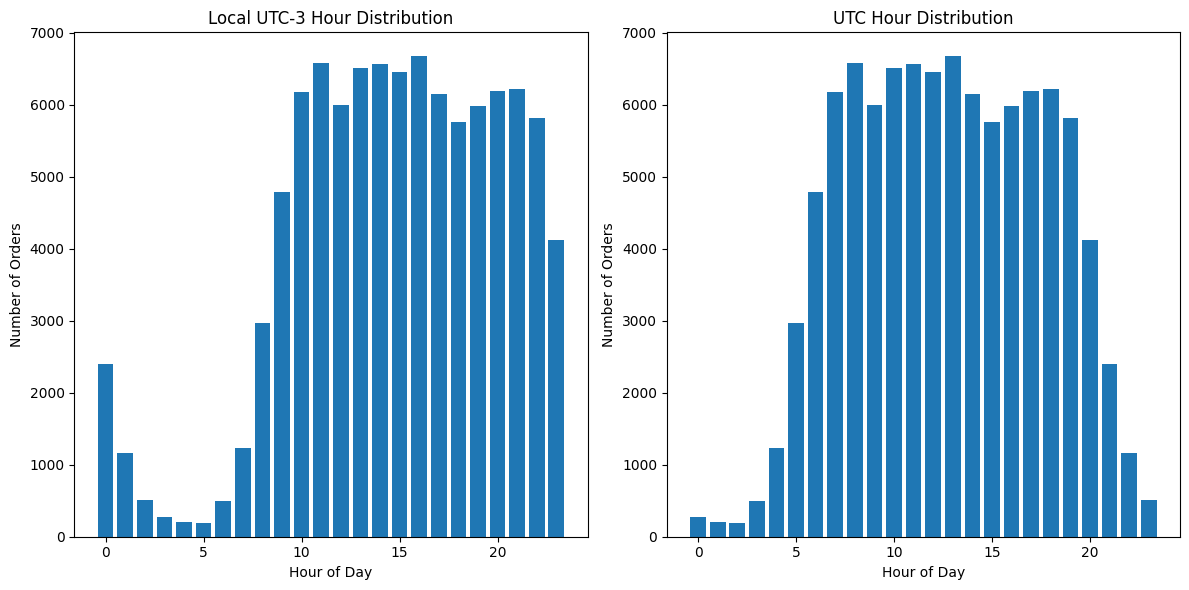

In [32]:
# Check if the timestamp columns are in Brazilian standard time (UTC-3) or UTC
# Assuming the timestamps are in UTC-3 brazilian time
orders["local_hour"] = orders["order_purchase_timestamp"].dt.hour

# Assuming the timestamps are in UTC time, need to convert to local time (UTC-3)
orders["utc_hour"] = (orders["order_purchase_timestamp"] + pd.Timedelta(hours=-3)).dt.hour

local_hourly_distribution = orders["local_hour"].value_counts().sort_index()
utc_hourly_distribution = orders["utc_hour"].value_counts().sort_index()


# Plot the distributions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(local_hourly_distribution.index, local_hourly_distribution.values)
plt.title("Local UTC-3 Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.subplot(1, 2, 2)
plt.bar(utc_hourly_distribution.index, utc_hourly_distribution.values)
plt.title("UTC Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## Check Referential Integrity

In [ ]:
# `orders.customer_id` references `customers.customer_id`
missing_customer_ids = ~orders["customer_id"].isin(customers["customer_id"])
num_missing_customer_ids = missing_customer_ids.sum()
print(f"Number of orders with missing customer_id references: {num_missing_customer_ids}")

Number of orders with missing customer_id references: 0


In [ ]:
# `order_reviews.order_id` references `orders.order_id`
missing_review_order_ids = ~order_reviews["order_id"].isin(orders["order_id"])
num_missing_review_order_ids = missing_review_order_ids.sum()
print(f"Number of order reviews with missing order_id references: {num_missing_review_order_ids}")

Number of order reviews with missing order_id references: 0


In [35]:
# `order_payments.order_id` references `orders.order_id`
missing_payment_order_ids = ~order_payments["order_id"].isin(orders["order_id"])
num_missing_payment_order_ids = missing_payment_order_ids.sum()
print(f"Number of order payments with missing order_id references: {num_missing_payment_order_ids}")

Number of order payments with missing order_id references: 0


In [36]:
# `order_items.order_id` references `orders.order_id`
missing_item_order_ids = ~order_items["order_id"].isin(orders["order_id"])
num_missing_item_order_ids = missing_item_order_ids.sum()
print(f"Number of order items with missing order_id references: {num_missing_item_order_ids}")

# `order_items.product_id` references `products.product_id`
missing_item_product_ids = ~order_items["product_id"].isin(products["product_id"])
num_missing_item_product_ids = missing_item_product_ids.sum()
print(f"Number of order items with missing product_id references: {num_missing_item_product_ids}")

# `order_items.seller_id` references `sellers.seller_id`
missing_item_seller_ids = ~order_items["seller_id"].isin(sellers["seller_id"])
num_missing_item_seller_ids = missing_item_seller_ids.sum()
print(f"Number of order items with missing seller_id references: {num_missing_item_seller_ids}")

Number of order items with missing order_id references: 0
Number of order items with missing product_id references: 0
Number of order items with missing seller_id references: 0


In [38]:
# `sellers.seller_zip_code_prefix` references `geolocation.geolocation_zip_code_prefix`
missing_seller_zip_codes = ~sellers["seller_zip_code_prefix"].isin(geolocation["geolocation_zip_code_prefix"])
num_missing_seller_zip_codes = missing_seller_zip_codes.sum()
print(f"Number of sellers with missing zip_code_prefix references: {num_missing_seller_zip_codes}")

# `customers.customer_zip_code_prefix` references `geolocation.geolocation_zip_code_prefix`
missing_customer_zip_codes = ~customers["customer_zip_code_prefix"].isin(geolocation["geolocation_zip_code_prefix"])
num_missing_customer_zip_codes = missing_customer_zip_codes.sum()
print(f"Number of customers with missing zip_code_prefix references: {num_missing_customer_zip_codes}")

Number of sellers with missing zip_code_prefix references: 7
Number of customers with missing zip_code_prefix references: 278
